# TSTR Evaluation

Evaluate **Train-Synthetic-Test-Real** (TSTR) quality for VAE and CVAE against the **Train-Real-Test-Real** (TRTR) upper bound.

Metrics: Accuracy, weighted F1, ROC-AUC (OvR), Log Loss, per-class F1, feature overlap (top-10 SHAP).

In [1]:
import json, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

RESULT_DIR = 'results/tstr'
CLASSES = ['bradypnea', 'eupnea', 'tachypnea']
MODEL_ORDER = ['trtr', 'cvae', 'vae']
REGION_ORDER = ['mouth', 'nose']

# Load all JSON results
records = []
for path in glob.glob(f'{RESULT_DIR}/*.json'):
    with open(path) as f:
        records.append(json.load(f))

df = pd.read_csv(f'{RESULT_DIR}/summary.csv')
df['model'] = pd.Categorical(df['model'], categories=MODEL_ORDER, ordered=True)
df = df.sort_values(['region', 'model']).reset_index(drop=True)

# Colour palette per model
COLORS = {'trtr': '#2c7bb6', 'cvae': '#1a9641', 'vae': '#d7191c'}
REGION_STYLE = {'mouth': '-', 'nose': '--'}

print(df.to_string(index=False))

model region  accuracy  f1_weighted  roc_auc_ovr  log_loss  f1_bradypnea  f1_eupnea  f1_tachypnea  feature_overlap  n_synthetic
 trtr  mouth  0.928571     0.925897     1.000000  0.225687      0.875000   0.947368      0.952381              NaN          215
 cvae  mouth  0.857143     0.856746     0.939084  0.458379      0.900000   0.777778      0.888889              0.4          215
  vae  mouth  0.321429     0.316153     0.481189  1.116679      0.555556   0.125000      0.272727              0.4          215
 trtr   nose  0.815789     0.815366     0.948761  0.434093      0.846154   0.814815      0.782609              NaN          298
 cvae   nose  0.473684     0.480064     0.705427  1.165869      0.484848   0.666667      0.272727              0.5          298
  vae   nose  0.263158     0.205354     0.323675  1.144290      0.000000   0.432432      0.181818              0.6          298


## 1 – Data utility score (TSTR / TRTR)

The **data utility score** = TSTR metric / TRTR metric.  A score of 1 means synthetic data is indistinguishable from real; 0 means it adds no value.

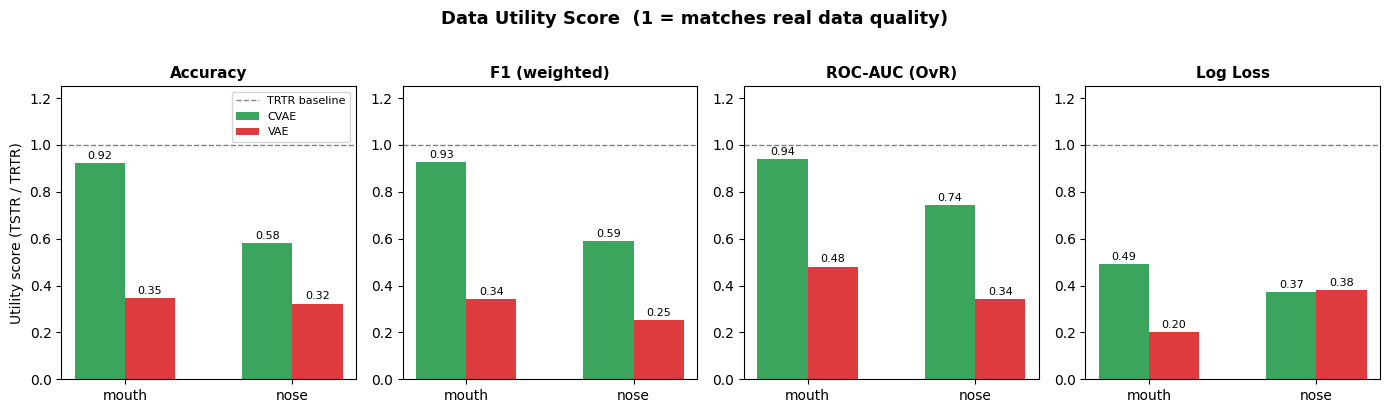

model region  accuracy  f1_weighted  roc_auc_ovr  log_loss
 cvae  mouth     0.923        0.925        0.939     0.492
  vae  mouth     0.346        0.341        0.481     0.202
 cvae   nose     0.581        0.589        0.744     0.372
  vae   nose     0.323        0.252        0.341     0.379


In [ ]:
metrics_main = ['accuracy', 'f1_weighted', 'roc_auc_ovr', 'log_loss']
metric_labels = ['Accuracy', 'F1 (weighted)', 'ROC-AUC (OvR)', 'Log Loss']

# Compute utility score relative to trtr per region
rows = []
for region in REGION_ORDER:
    trtr_row = df[(df.model == 'trtr') & (df.region == region)].iloc[0]
    for model in ['cvae', 'vae']:
        r = df[(df.model == model) & (df.region == region)].iloc[0]
        entry = {'model': model, 'region': region}
        for m in metrics_main:
            t = trtr_row[m]
            v = r[m]
            # for log_loss lower is better → invert ratio
            if m == 'log_loss':
                entry[m] = t / v if v > 0 else np.nan
            else:
                entry[m] = v / t if t > 0 else np.nan
        rows.append(entry)

util_df = pd.DataFrame(rows)

fig, axes = plt.subplots(1, len(metrics_main), figsize=(14, 4), sharey=False)
x = np.arange(2)  # two regions
width = 0.3

for ax, m, label in zip(axes, metrics_main, metric_labels):
    for i, model in enumerate(['cvae', 'vae']):
        vals = [util_df[(util_df.model == model) & (util_df.region == r)][m].values[0] for r in REGION_ORDER]
        bars = ax.bar(x + i * width, vals, width, label=model.upper(), color=COLORS[model], alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=8)
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, label='TRTR baseline')
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(REGION_ORDER)
    ax.set_ylim(0, 1.25)
    ax.set_ylabel('Utility score (TSTR / TRTR)' if label == metric_labels[0] else '')
    ax.legend(fontsize=8) if m == metrics_main[0] else None

fig.suptitle('Data Utility Score  (1 = matches real data quality)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(util_df.round(3).to_string(index=False))

## 2 – Absolute metric comparison (all models, both regions)

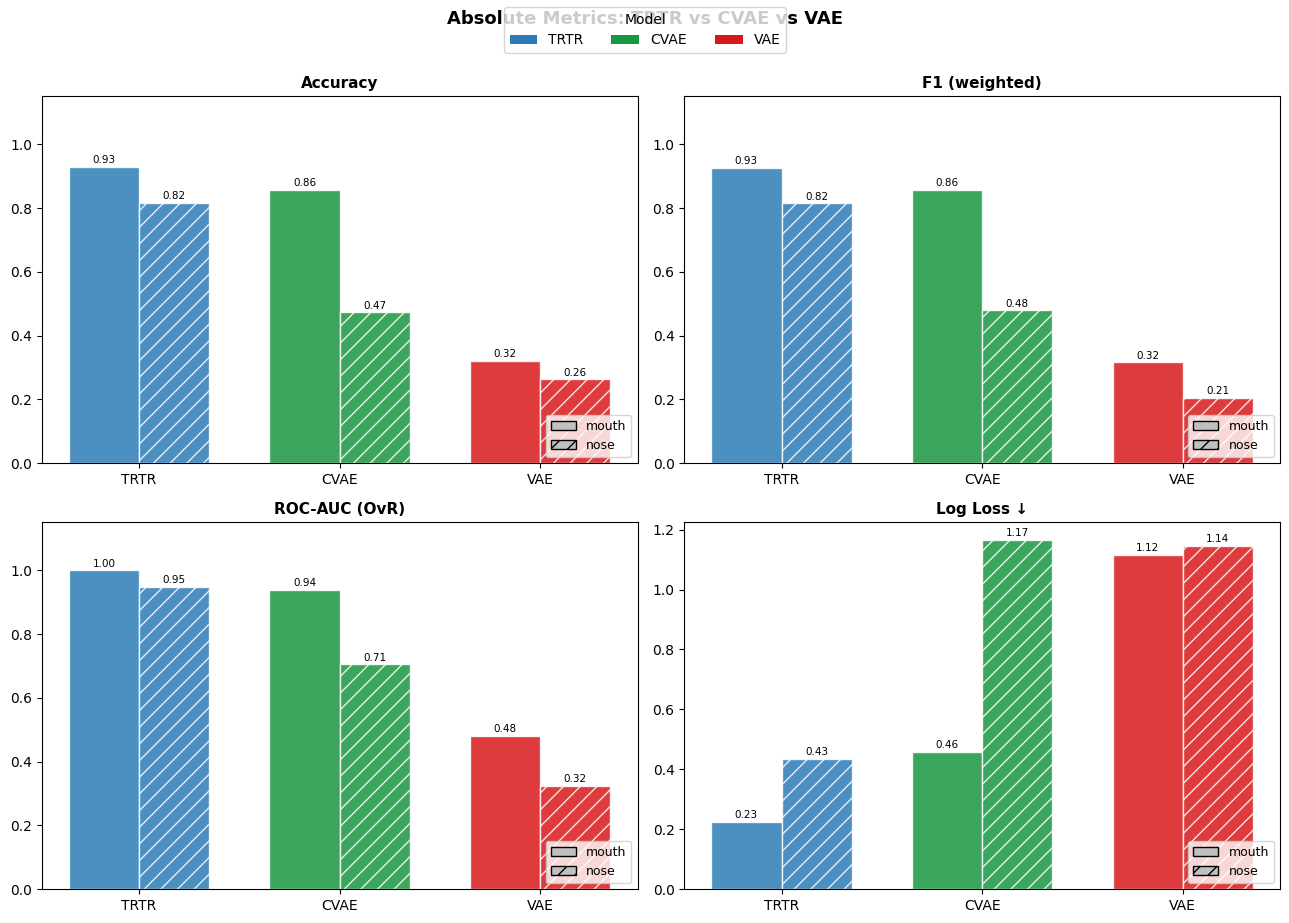

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

metrics_abs = ['accuracy', 'f1_weighted', 'roc_auc_ovr', 'log_loss']
metric_labels_abs = ['Accuracy', 'F1 (weighted)', 'ROC-AUC (OvR)', 'Log Loss ↓']
invert = [False, False, False, True]  # log_loss: lower is better

x = np.arange(len(MODEL_ORDER))
width = 0.35
hatch = {'mouth': '', 'nose': '//'}

for ax, m, label, inv in zip(axes, metrics_abs, metric_labels_abs, invert):
    for j, region in enumerate(REGION_ORDER):
        vals = [df[(df.model == mo) & (df.region == region)][m].values[0] for mo in MODEL_ORDER]
        bars = ax.bar(x + j * width, vals, width,
                      label=region,
                      color=[COLORS[mo] for mo in MODEL_ORDER],
                      hatch=hatch[region],
                      alpha=0.85,
                      edgecolor='white')
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005 * (ax.get_ylim()[1] if ax.get_ylim()[1] else 1),
                    f'{v:.2f}', ha='center', va='bottom', fontsize=7.5, rotation=0)

    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels([m.upper() for m in MODEL_ORDER])
    if not inv:
        ax.set_ylim(0, 1.15)

    # region legend (hatch pattern)
    legend_patches = [mpatches.Patch(facecolor='silver', edgecolor='black', hatch=hatch[r], label=r) for r in REGION_ORDER]
    ax.legend(handles=legend_patches, fontsize=9, loc='lower right')

model_patches = [mpatches.Patch(facecolor=COLORS[m], label=m.upper()) for m in MODEL_ORDER]
fig.legend(handles=model_patches, loc='upper center', ncol=3, fontsize=10, title='Model', title_fontsize=10)
fig.suptitle('Absolute Metrics: TRTR vs CVAE vs VAE', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3 – Per-class F1 heatmap

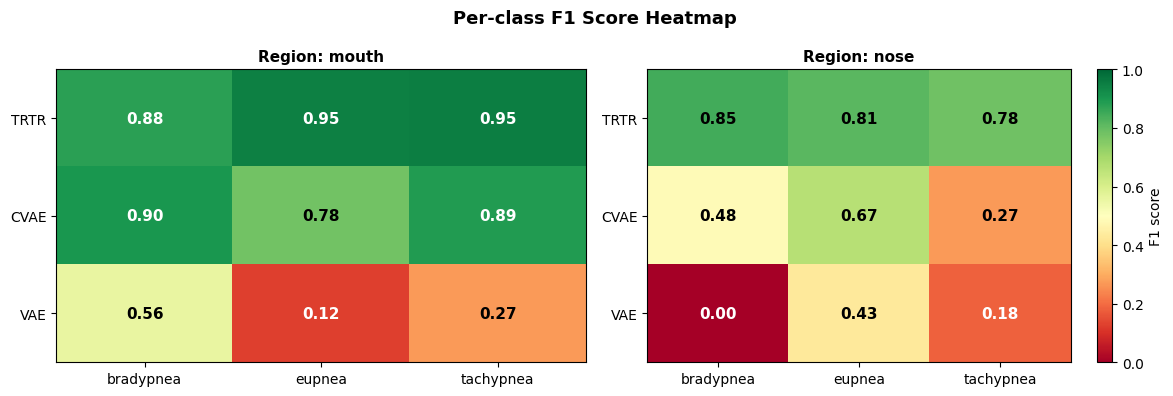

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, region in zip(axes, REGION_ORDER):
    matrix = []
    row_labels = []
    for model in MODEL_ORDER:
        r = df[(df.model == model) & (df.region == region)].iloc[0]
        matrix.append([r['f1_bradypnea'], r['f1_eupnea'], r['f1_tachypnea']])
        row_labels.append(model.upper())

    mat = np.array(matrix)
    im = ax.imshow(mat, vmin=0, vmax=1, cmap='RdYlGn', aspect='auto')

    ax.set_xticks(range(len(CLASSES)))
    ax.set_xticklabels(CLASSES, fontsize=10)
    ax.set_yticks(range(len(MODEL_ORDER)))
    ax.set_yticklabels(row_labels, fontsize=10)
    ax.set_title(f'Region: {region}', fontsize=11, fontweight='bold')

    for i in range(len(MODEL_ORDER)):
        for j in range(len(CLASSES)):
            v = mat[i, j]
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    fontsize=11, color='black' if 0.25 < v < 0.85 else 'white',
                    fontweight='bold')

plt.colorbar(im, ax=axes[-1], label='F1 score')
fig.suptitle('Per-class F1 Score Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4 – Feature overlap (top-10 SHAP)

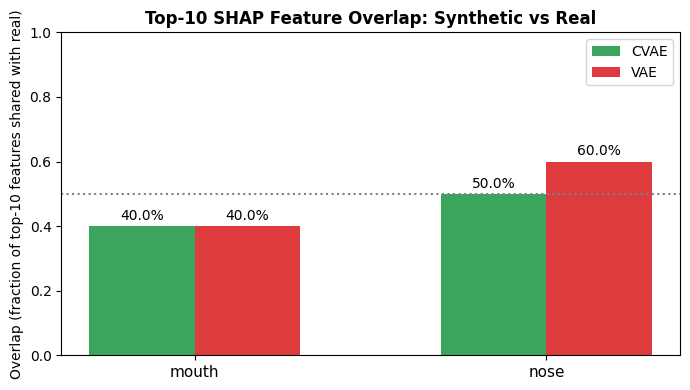

Feature overlap (top-10 SHAP importance, synthetic vs real):

  Region: mouth
    CVAE : 40.0%  (4/10 features match real)
    VAE  : 40.0%  (4/10 features match real)

  Region: nose
    CVAE : 50.0%  (5/10 features match real)
    VAE  : 60.0%  (6/10 features match real)


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

x = np.arange(2)
width = 0.3

for i, model in enumerate(['cvae', 'vae']):
    vals = [df[(df.model == model) & (df.region == r)]['feature_overlap'].values[0] for r in REGION_ORDER]
    bars = ax.bar(x + i * width, vals, width, label=model.upper(), color=COLORS[model], alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{v:.1%}', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(REGION_ORDER, fontsize=11)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Overlap (fraction of top-10 features shared with real)')
ax.set_title('Top-10 SHAP Feature Overlap: Synthetic vs Real', fontsize=12, fontweight='bold')
ax.legend()
ax.axhline(0.5, color='gray', linestyle=':', label='50% reference')
plt.tight_layout()
plt.show()

# Print feature overlap table with interpretation
print('Feature overlap (top-10 SHAP importance, synthetic vs real):')
for region in REGION_ORDER:
    print(f'\n  Region: {region}')
    for model in ['cvae', 'vae']:
        v = df[(df.model == model) & (df.region == region)]['feature_overlap'].values[0]
        print(f'    {model.upper():5s}: {v:.1%}  ({int(v*10)}/10 features match real)')

## 5 – Summary table with relative performance

In [6]:
rows = []
for region in REGION_ORDER:
    trtr = df[(df.model == 'trtr') & (df.region == region)].iloc[0]
    for model in MODEL_ORDER:
        r = df[(df.model == model) & (df.region == region)].iloc[0]
        acc_rel = r['accuracy'] / trtr['accuracy'] if model != 'trtr' else 1.0
        f1_rel  = r['f1_weighted'] / trtr['f1_weighted'] if model != 'trtr' else 1.0
        rows.append({
            'Region': region,
            'Model': model.upper(),
            'Accuracy': f"{r['accuracy']:.3f}",
            'Acc %TRTR': f"{acc_rel:.1%}",
            'F1-weighted': f"{r['f1_weighted']:.3f}",
            'F1 %TRTR': f"{f1_rel:.1%}",
            'ROC-AUC': f"{r['roc_auc_ovr']:.3f}",
            'Log Loss': f"{r['log_loss']:.3f}",
            'Feat. Overlap': f"{r['feature_overlap']:.1%}" if pd.notna(r['feature_overlap']) else '—',
        })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

print('\n--- Key takeaways ---')
for region in REGION_ORDER:
    trtr_acc = df[(df.model == 'trtr') & (df.region == region)].iloc[0]['accuracy']
    for model in ['cvae', 'vae']:
        r = df[(df.model == model) & (df.region == region)].iloc[0]
        pct = r['accuracy'] / trtr_acc
        print(f'  {model.upper()} ({region}): {pct:.1%} of TRTR accuracy  '
              f'({r["accuracy"]:.3f} vs {trtr_acc:.3f})')

Region Model Accuracy Acc %TRTR F1-weighted F1 %TRTR ROC-AUC Log Loss Feat. Overlap
 mouth  TRTR    0.929    100.0%       0.926   100.0%   1.000    0.226             —
 mouth  CVAE    0.857     92.3%       0.857    92.5%   0.939    0.458         40.0%
 mouth   VAE    0.321     34.6%       0.316    34.1%   0.481    1.117         40.0%
  nose  TRTR    0.816    100.0%       0.815   100.0%   0.949    0.434             —
  nose  CVAE    0.474     58.1%       0.480    58.9%   0.705    1.166         50.0%
  nose   VAE    0.263     32.3%       0.205    25.2%   0.324    1.144         60.0%

--- Key takeaways ---
  CVAE (mouth): 92.3% of TRTR accuracy  (0.857 vs 0.929)
  VAE (mouth): 34.6% of TRTR accuracy  (0.321 vs 0.929)
  CVAE (nose): 58.1% of TRTR accuracy  (0.474 vs 0.816)
  VAE (nose): 32.3% of TRTR accuracy  (0.263 vs 0.816)


## 6 – Radar / spider chart (multi-metric profile per model)

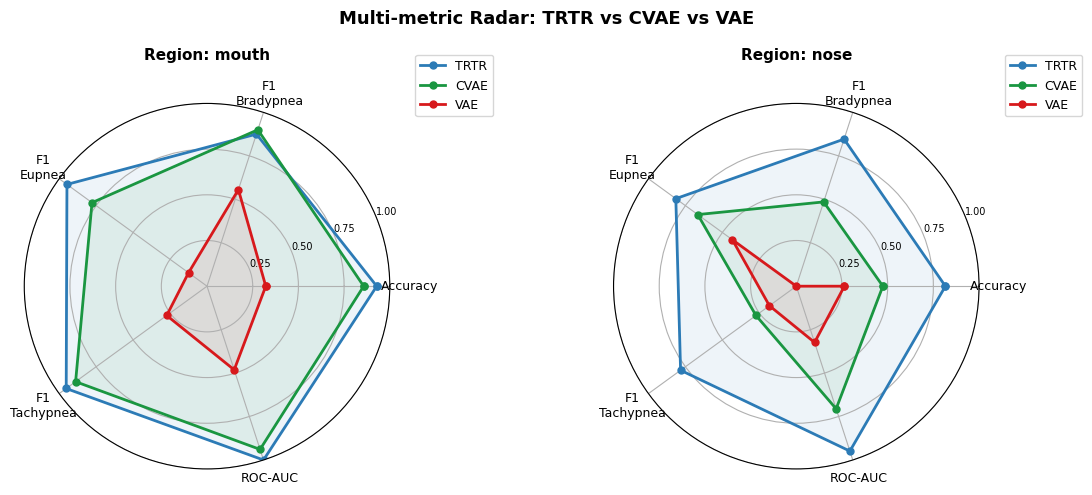

In [ ]:
from matplotlib.patches import FancyArrowPatch

radar_metrics = ['accuracy', 'f1_bradypnea', 'f1_eupnea', 'f1_tachypnea', 'roc_auc_ovr']
radar_labels  = ['Accuracy', 'F1\nBradypnea', 'F1\nEupnea', 'F1\nTachypnea', 'ROC-AUC']
N = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close polygon

fig, axes = plt.subplots(1, 2, figsize=(12, 5), subplot_kw=dict(polar=True))

for ax, region in zip(axes, REGION_ORDER):
    for model in MODEL_ORDER:
        r = df[(df.model == model) & (df.region == region)].iloc[0]
        values = [r[m] for m in radar_metrics]
        values += values[:1]
        ax.plot(angles, values, '-o', color=COLORS[model], linewidth=2,
                label=model.upper(), markersize=5)
        ax.fill(angles, values, color=COLORS[model], alpha=0.08)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=7)
    ax.set_title(f'Region: {region}', fontsize=11, fontweight='bold', pad=15)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15), fontsize=9)

fig.suptitle('Multi-metric Radar: TRTR vs CVAE vs VAE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7 – Interpretation & findings

In [8]:
from IPython.display import Markdown

lines = ['| Finding | Detail |', '|---|---|']

for region in REGION_ORDER:
    trtr_acc = df[(df.model == 'trtr') & (df.region == region)].iloc[0]['accuracy']
    trtr_roc = df[(df.model == 'trtr') & (df.region == region)].iloc[0]['roc_auc_ovr']
    for model in ['cvae', 'vae']:
        r = df[(df.model == model) & (df.region == region)].iloc[0]
        acc_pct = r['accuracy'] / trtr_acc
        roc_pct = r['roc_auc_ovr'] / trtr_roc
        worst_class = min(zip([r['f1_bradypnea'], r['f1_eupnea'], r['f1_tachypnea']], CLASSES))[1]
        lines.append(
            f"| **{model.upper()} – {region}** | "
            f"Accuracy {r['accuracy']:.3f} ({acc_pct:.0%} of TRTR), "
            f"ROC-AUC {r['roc_auc_ovr']:.3f} ({roc_pct:.0%} of TRTR), "
            f"worst class: *{worst_class}* (F1={min(r['f1_bradypnea'], r['f1_eupnea'], r['f1_tachypnea']):.2f}), "
            f"feature overlap {r['feature_overlap']:.0%} |"
        )

display(Markdown('\n'.join(lines)))

# Gap to TRTR
print('\n=== Performance gap to TRTR upper bound ===')
for region in REGION_ORDER:
    trtr_f1 = df[(df.model == 'trtr') & (df.region == region)].iloc[0]['f1_weighted']
    print(f'\n{region.upper()}:')
    for model in ['cvae', 'vae']:
        r = df[(df.model == model) & (df.region == region)].iloc[0]
        gap = trtr_f1 - r['f1_weighted']
        print(f'  {model.upper():5s}: F1 gap = {gap:+.3f}  ({r["f1_weighted"]:.3f} vs TRTR {trtr_f1:.3f})')

| Finding | Detail |
|---|---|
| **CVAE – mouth** | Accuracy 0.857 (92% of TRTR), ROC-AUC 0.939 (94% of TRTR), worst class: *eupnea* (F1=0.78), feature overlap 40% |
| **VAE – mouth** | Accuracy 0.321 (35% of TRTR), ROC-AUC 0.481 (48% of TRTR), worst class: *eupnea* (F1=0.12), feature overlap 40% |
| **CVAE – nose** | Accuracy 0.474 (58% of TRTR), ROC-AUC 0.705 (74% of TRTR), worst class: *tachypnea* (F1=0.27), feature overlap 50% |
| **VAE – nose** | Accuracy 0.263 (32% of TRTR), ROC-AUC 0.324 (34% of TRTR), worst class: *bradypnea* (F1=0.00), feature overlap 60% |


=== Performance gap to TRTR upper bound ===

MOUTH:
  CVAE : F1 gap = +0.069  (0.857 vs TRTR 0.926)
  VAE  : F1 gap = +0.610  (0.316 vs TRTR 0.926)

NOSE:
  CVAE : F1 gap = +0.335  (0.480 vs TRTR 0.815)
  VAE  : F1 gap = +0.610  (0.205 vs TRTR 0.815)
